In [1]:
import os
os.makedirs('results/eda_visualizations', exist_ok=True)
print("Folder created!")


Folder created!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv('BankChurners.csv')

# Check for duplicate rows before doing anything else
print(f"Duplicate rows found: {df.duplicated().sum()}")

# Remove duplicate rows (keeps first occurrence, drops exact repeats)
# Done BEFORE the train/test split so a duplicate customer can never end up
# in both splits at once (which would leak information between them)
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")

# Drop identifier column and separate features from target
X = df.drop(columns=['CLIENTNUM', 'Attrition_Flag'])
y = (df['Attrition_Flag'] == 'Attrited Customer').astype(int)

# Stratified Train/Test split to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")


Duplicate rows found: 0
Shape after removing duplicates: (10127, 23)
Training samples: 8101, Testing samples: 2026


In [3]:
# BankChurners.csv contains 0 duplicate rows, so a small artificial demo
# is used here to verify the detection/removal logic actually works
df_demo = pd.concat([df, df.iloc[0:3]], ignore_index=True)
print(f"Demo shape after injecting 3 duplicate rows: {df_demo.shape}")

# Detect duplicates (True = row is an exact repeat of an earlier row)
duplicate_flags = df_demo.duplicated()
print(f"Duplicate rows detected: {duplicate_flags.sum()}")

# Remove duplicates and verify the shape returns to normal
df_demo_cleaned = df_demo.drop_duplicates()
print(f"Shape after removing duplicates: {df_demo_cleaned.shape}")
print(f"Duplicate rows remaining: {df_demo_cleaned.duplicated().sum()}")


Demo shape after injecting 3 duplicate rows: (10130, 23)
Duplicate rows detected: 3
Shape after removing duplicates: (10127, 23)
Duplicate rows remaining: 0


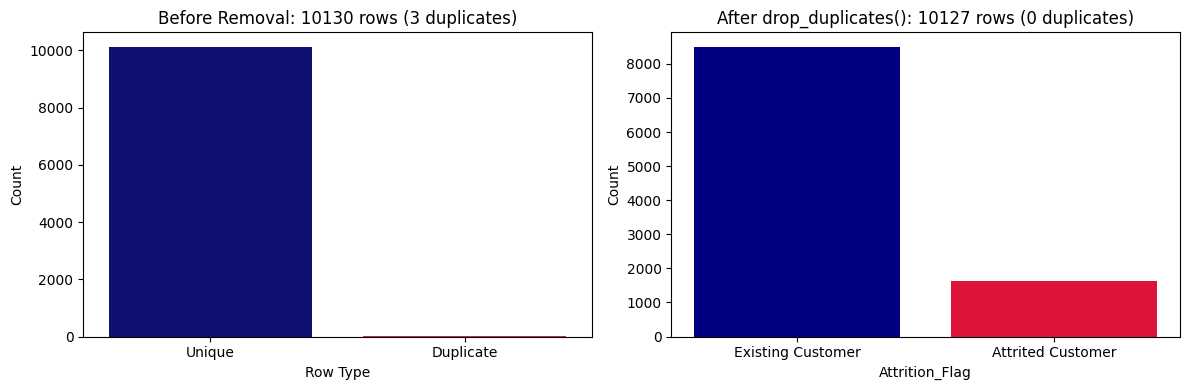

Plot successfully saved to: results/eda_visualizations/IT25102086_duplicate_removal_comparison.png


In [4]:
# Create the required before vs. after comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before removal (demo dataset with 3 injected duplicate rows)
sns.countplot(x=df_demo.duplicated().map({False: 'Unique', True: 'Duplicate'}),
              ax=axes[0], hue=df_demo.duplicated().map({False: 'Unique', True: 'Duplicate'}),
              palette={'Unique': 'navy', 'Duplicate': 'crimson'}, legend=False)
axes[0].set_title(f'Before Removal: {df_demo.shape[0]} rows ({duplicate_flags.sum()} duplicates)')
axes[0].set_xlabel('Row Type')
axes[0].set_ylabel('Count')

# After removal
axes[1].bar(['Existing Customer', 'Attrited Customer'],
            df_demo_cleaned['Attrition_Flag'].value_counts()[['Existing Customer', 'Attrited Customer']],
            color=['navy', 'crimson'])
axes[1].set_title(f'After drop_duplicates(): {df_demo_cleaned.shape[0]} rows (0 duplicates)')
axes[1].set_xlabel('Attrition_Flag')
axes[1].set_ylabel('Count')

plt.tight_layout()

# Save image file to deliverable directory
plot_path = 'results/eda_visualizations/IT25102086_duplicate_removal_comparison.png'
plt.savefig(plot_path, dpi=300)
plt.show()
print(f"Plot successfully saved to: {plot_path}")
